<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/Clase_2_repaso_de_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras

#Arquitectura

In [ ]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [ ]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [ ]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

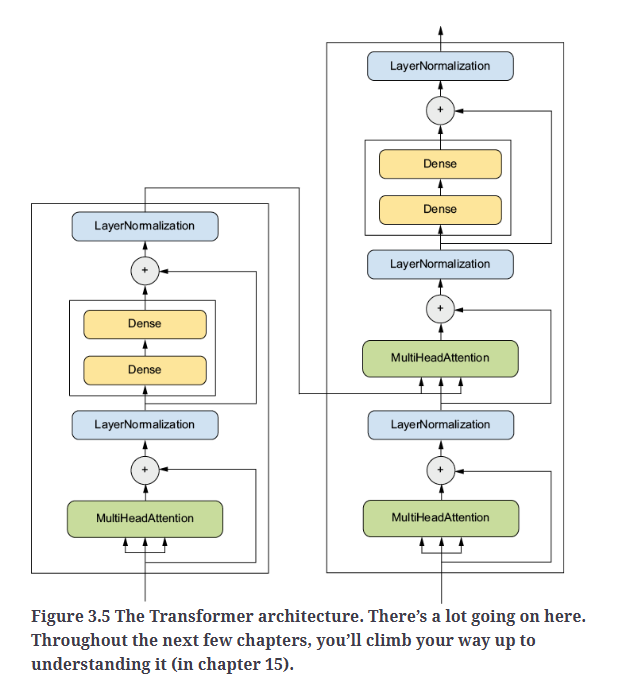

#Compilar

Una vez definida la arquitectura del modelo, se debe elegir tres cosas más:

* **Función de pérdida (*Loss function* / Función objetivo):** Es la cantidad que se minimizará durante el entrenamiento. Representa una medida del éxito para la tarea en cuestión.
* **Optimizador (*Optimizer*):** Determina cómo se actualizará la red en función de la función de pérdida. Implementa una variante específica del descenso de gradiente estocástico (SGD).
* **Métricas (*Metrics*):** Las medidas de éxito que deseas monitorear durante el entrenamiento y la validación, como la precisión de la clasificación (*accuracy*). A diferencia de la pérdida, el entrenamiento no optimizará directamente estas métricas; por lo tanto, las métricas no necesitan ser diferenciables.

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

### ¿Qué significa `optimizer="rmsprop"`?

Esta línea le indica al modelo qué **estrategia matemática** debe usar para actualizar sus pesos y reducir el error (la pérdida) durante el entrenamiento.

* **RMSprop** significa *Root Mean Square Propagation*.
* **¿Cómo funciona?** A diferencia del descenso de gradiente tradicional, RMSprop ajusta el paso de aprendizaje de forma individual para cada parámetro, basándose en la media móvil de los gradientes recientes.


#Ajustar o entrenar

Después de `compile()` viene `fit()`. El método `fit` implementa el bucle de entrenamiento (*training loop*) propiamente dicho. Sus argumentos clave son:

* **Los datos (entradas y objetivos)** sobre los cuales entrenar. Por lo general, se pasan en forma de arreglos de NumPy o como un objeto `Dataset` de TensorFlow. Aprenderás más sobre la API de `Dataset` en los próximos capítulos.
* **El número de épocas (*epochs*)** de entrenamiento: cuántas veces debe iterar el bucle de entrenamiento sobre todos los datos proporcionados.
* **El tamaño del lote (*batch size*)** que se utilizará en cada época del descenso de gradiente por mini-lotes: la cantidad de ejemplos de entrenamiento considerados para calcular los gradientes en un solo paso de actualización de los pesos.

In [ ]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

In [ ]:
history.history

#Resumen

In [ ]:
import numpy as np

In [ ]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [ ]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [ ]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

In [ ]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.8193 - loss: 0.9573 - val_binary_accuracy: 0.9233 - val_loss: 0.0851
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9543 - loss: 0.0727 - val_binary_accuracy: 0.9983 - val_loss: 0.0274
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9600 - loss: 0.0660 - val_binary_accuracy: 0.9950 - val_loss: 0.0309
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9643 - loss: 0.0698 - val_binary_accuracy: 0.9950 - val_loss: 0.0397
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9636 - loss: 0.0694 - val_binary_accuracy: 0.9267 - val_loss: 0.1063


#prediccion

In [ ]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[0.25603864]
 [0.39366937]
 [0.01890624]
 [0.14157742]
 [0.53057086]
 [1.1117079 ]
 [0.8267697 ]
 [0.5362085 ]
 [1.2908797 ]
 [1.4147649 ]]
